### Visualizing all possible outputs
Use treeHMM_env.

- create mock model
- visualize all outputs

In [1]:
import pickle
import numpy as np

import zipfile
from io import BytesIO
import tifffile

import os

from pathlib import Path
import yaml

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/adamw/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')

from models.tarhmm import tree_hmm_two_filter_smoother


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/emissions_array.npy")

In [4]:
num_states = [3]

for state in num_states:
    num_states = state
    emission_dim = 3
    num_lags = 1

    emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/emissions_array.npy")
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/data.pkl", "rb") as f:
        data = pickle.load(f)
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/crop_and_cell_id_to_col.pkl", "rb") as f:
        crop_and_cell_id_to_col = pickle.load(f)

    arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
    params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions)
    inputs = arhmm.compute_inputs(
        jnp.array(emissions),
        jnp.array(data["parent_indices"]),
        jnp.array(data["is_division_mask"]),
        jnp.array(data["is_new_root_mask"]),
        jnp.array(data["active_mask"]),
    )

    # TODO: maybe fix this???
    batched_emissions = emissions
    batched_inputs = inputs
    batched_parent_indices = data["parent_indices"]
    batched_is_division_mask = data["is_division_mask"]
    batched_active_mask = data["active_mask"]
    batched_is_new_root_mask = data["is_new_root_mask"]

    fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

    # Compute the posterior distribution of the latent states
    input_fwd = arhmm._inference_args(params, emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])

    posterior = tree_hmm_two_filter_smoother(*input_fwd)

    # save state assignments
    state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)  # (50, 110)

    # data_output_dir = "/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/all_gt_crops_pretrained_SAM3/"
    # np.save(os.path.join(data_output_dir, f"state_assignments_{num_states}_states.npy"), state_assignments)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:01&lt;00:00]</div>

In [5]:
posterior.smoothed_probs.shape

(50, 326, 3)

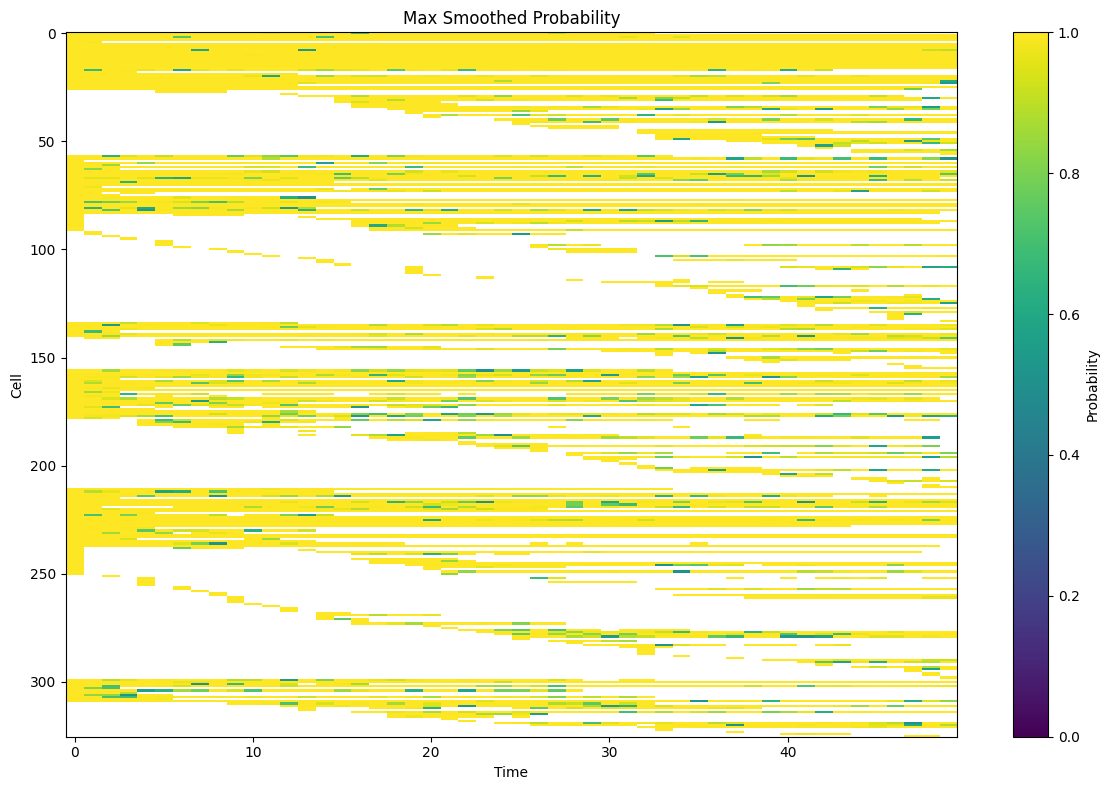

In [6]:
max_probs = jnp.max(posterior.smoothed_probs, axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

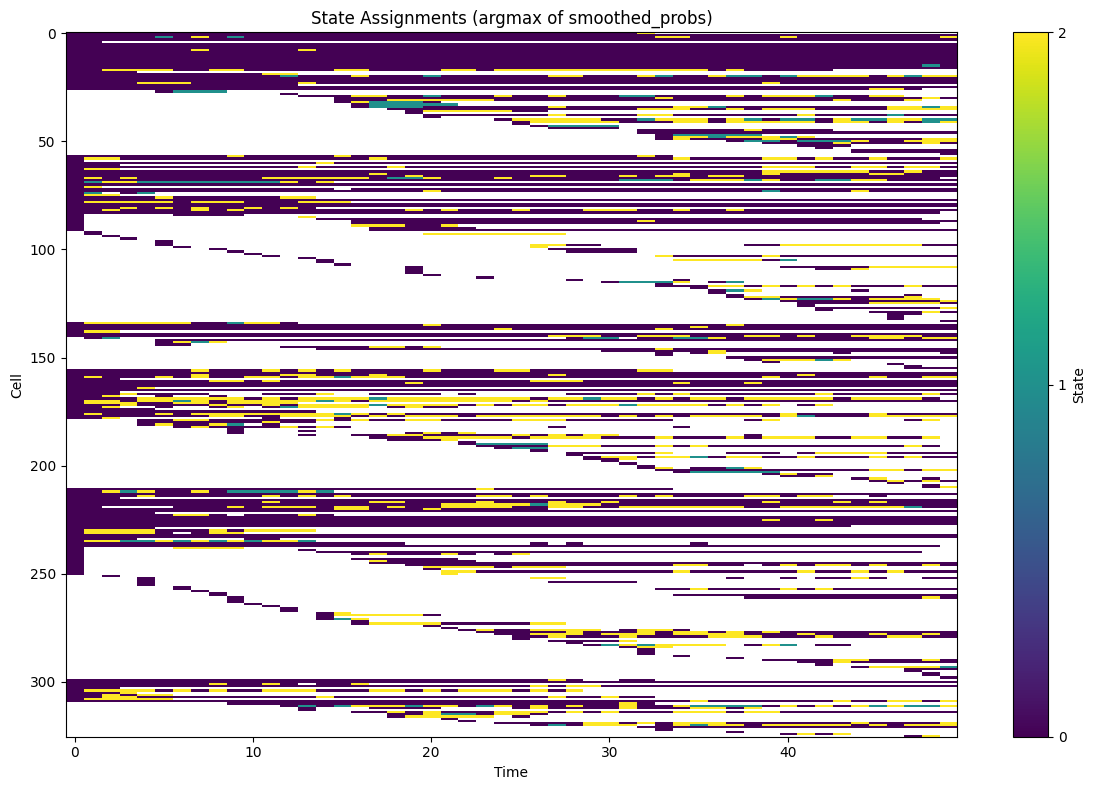

In [7]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

In [8]:
params

ParamsLinearTreeARHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.511915  , 0.1841986 , 0.30388635], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.20116308, 0.18698764, 0.6118493 ],
       [0.35639635, 0.6150627 , 0.02854097],
       [0.00594629, 0.6042356 , 0.3898181 ]], dtype=float32)), division_transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.579266  , 0.37945727, 0.04127672],
       [0.17603847, 0.02326343, 0.8006981 ],
       [0.1893038 , 0.442532  , 0.36816415]], dtype=float32)), emissions=ParamsLinearRegressionHMMEmissions(weights=Array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32), biases=Array([[ 0.89459705,  0.47216952,  0.6725174 ],
       [14.755212  ,  0.46341464,  0.4390244 ],
       [ 5.014302  ,  0.6232316 ,  0.48473567]], dtype=float32),

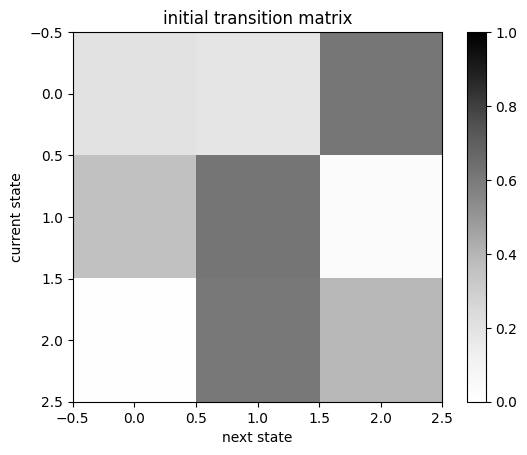

In [9]:
initial_transitions = params.transitions.transition_matrix
plt.imshow(initial_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("initial transition matrix")
plt.colorbar()

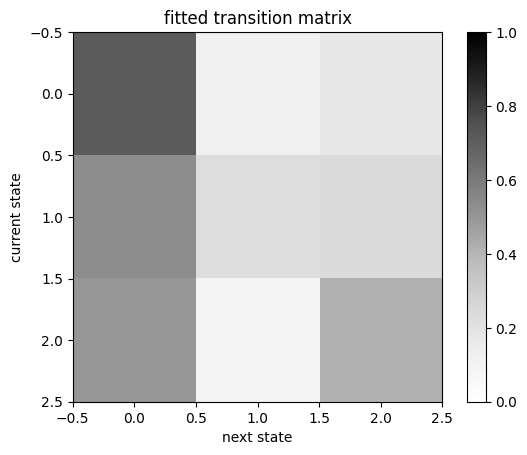

In [10]:
fitted_transitions = fitted_params.transitions.transition_matrix
plt.imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("fitted transition matrix")
plt.colorbar()

In [11]:
fitted_init_raw = np.array(fitted_params.initial.probs)
fitted_init_raw

array([0.64387363, 0.00970083, 0.34642553], dtype=float32)

In [12]:
initial_init_raw = np.array(params.initial.probs)
initial_init_raw

array([0.511915  , 0.1841986 , 0.30388635], dtype=float32)